In [1]:
# shell
# python -m venv .venv       

# In cmd.exe
# .venv\Scripts\activate.bat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from tqdm.notebook import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
"""
import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from einops import rearrange, repeat
from einops.layers.torch import Rearrange"""

'\nimport torch\nimport torch.nn.functional as F\nfrom torch import nn\nfrom torch import Tensor\nfrom einops import rearrange, repeat\nfrom einops.layers.torch import Rearrange'

In [3]:
import umap 

Explored various type of models:
- VAE: Not very effective on the categorical data, despite the sentence embedding;
- RAG: Very effective on the categorical data. We can compute the cosine similarity on each feature in the dataset.
- KNN: One hot encoding on the categorical data. Leads to very high dimensional observation.

Loading the dataset

In [2]:
# https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows
# https://www.kaggle.com/code/samad0015/eda-on-netflix-shows
path = "../data/netflix_titles.csv"
df = pd.read_csv(path)

df.shape

(8807, 12)

In [3]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


<br>
<br>

Remove row with NA in rating and duration 

In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['cast']     = df['cast'].apply(lambda x: ' '.join(x.split()[:150]))

df.drop(columns='date_added', inplace=True)
df_clean = df.dropna()
df_clean = df_clean.reset_index()
df_clean_backup = df_clean.copy()

n, d = df_clean.shape

<br>
<br>
<br>

### KNN

In [245]:
mlb = MultiLabelBinarizer()

In [246]:
df_clean = df_clean_backup.copy()

df_clean['cast'] = df_clean['cast'].apply(lambda x: [i.strip() for i in str(x).split(',')])

one_hot = pd.DataFrame(mlb.fit_transform(df_clean['cast']), columns=[f"cast_{cls}" for cls in mlb.classes_], dtype=int)

df_clean = df_clean.reset_index(drop=True)
one_hot = one_hot.reset_index(drop=True)

df_encoded = pd.concat([df_clean.drop(columns='cast'), one_hot], axis=1)

In [247]:
df_encoded['director'] = df_encoded['director'].apply(lambda x: [i.strip() for i in str(x).split(',')])

one_hot = pd.DataFrame(mlb.fit_transform(df_encoded['director']), columns=[f"director_{cls}" for cls in mlb.classes_], dtype=int)

df_encoded = df_encoded.reset_index(drop=True)
one_hot = one_hot.reset_index(drop=True)

df_encoded = pd.concat([df_encoded.drop(columns='director'), one_hot], axis=1)

In [248]:
df_encoded['country'] = df_encoded['country'].apply(lambda x: [i.strip() for i in str(x).split(',')])

one_hot = pd.DataFrame(mlb.fit_transform(df_encoded['country']), columns=[f"country_{cls}" for cls in mlb.classes_], dtype=int)

df_encoded = df_encoded.reset_index(drop=True)
one_hot = one_hot.reset_index(drop=True)

df_encoded = pd.concat([df_encoded.drop(columns='country'), one_hot], axis=1)

In [249]:
df_encoded['listed_in'] = df_encoded['listed_in'].apply(lambda x: [i.strip() for i in str(x).split(',')])

one_hot = pd.DataFrame(mlb.fit_transform(df_encoded['listed_in']), columns=[f"listed_in_{cls}" for cls in mlb.classes_], dtype=int)

df_encoded = df_encoded.reset_index(drop=True)
one_hot = one_hot.reset_index(drop=True)

df_encoded = pd.concat([df_encoded.drop(columns='listed_in'), one_hot], axis=1)

In [250]:
rating_adultness = {
    'TV-Y': 0,
    'TV-Y7': 1,
    'TV-Y7-FV': 2,
    'TV-G': 3,
    'G': 3,
    'TV-PG': 4,
    'PG': 4,
    'TV-14': 5,
    'PG-13': 6,
    'R': 7,
    'TV-MA': 8,
    'NC-17': 9,
    'NR': -1,
    'UR': -1
}
df_encoded['rating'] = df_encoded['rating'].map(rating_adultness)

In [251]:
X = df_encoded.drop(columns=['show_id', 'type', 'title', 'duration', 'description']).to_numpy(dtype='float32')

In [ ]:
class KNN:
    def __init__(self, k=10):
        self.k   = k
        self.res = k


    def fit(self, X):
        self.X = X
        self.n, self.d = X.shape


    def predict(self, X):
        n_movies = X.shape[0]
        idxs, distances = np.zeros((n_movies, self.res)), np.zeros((n_movies, self.res))
        
        for i, x in enumerate(X):
            idxs[i] , distances[i] = self._predict(x)
        
        distances, idxs = distances.flatten(), idxs.flatten()
        
        idx_sort = np.argsort(distances)                                       # compute where the score is higher
        idxs_sorted = idxs[idx_sort]                                           # movie indexes with the higher score overall

        filter = ~np.isin(idxs_sorted, X)                                      # remove searched indexes
        _, unique_idx = np.unique(idxs_sorted[filter], return_index=True)      # get where there is the first new number

        return idxs_sorted[filter][np.sort(unique_idx)][:self.k]               # return the first k movie index
           

    def _predict(self, idx):
        x = self.X[idx]
        difference = (x - self.X)
        distances = np.sqrt(np.sum( difference*difference, axis=1))/self.n
        idx = np.argsort(distances)[1:self.res + 1]
        return idx, distances[idx]

In [253]:
knn = KNN()
knn.fit(X)

In [554]:
mask = df_clean['director'] == 'Steven Spielberg'
df_clean[mask]

,index,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
41,41,s42,Movie,Jaws,Steven Spielberg,"[Roy Scheider, Robert Shaw, Richard Dreyfuss, ...",United States,1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
329,329,s330,Movie,Catch Me If You Can,Steven Spielberg,"[Leonardo DiCaprio, Tom Hanks, Christopher Wal...","United States, Canada",2002,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...
1203,1203,s1204,Movie,The BFG,Steven Spielberg,"[Mark Rylance, Ruby Barnhill, Penelope Wilton,...","United States, India, United Kingdom",2016,PG,118 min,"Children & Family Movies, Dramas",A little orphan meets up with a kind giant who...
7065,7070,s7071,Movie,Indiana Jones and the Kingdom of the Crystal S...,Steven Spielberg,"[Harrison Ford, Cate Blanchett, Karen Allen, R...",United States,2008,PG-13,123 min,"Action & Adventure, Children & Family Movies, ...",Indiana Jones is drawn into a Russian plot to ...
7066,7071,s7072,Movie,Indiana Jones and the Last Crusade,Steven Spielberg,"[Harrison Ford, Sean Connery, Denholm Elliott,...",United States,1989,PG-13,127 min,"Action & Adventure, Children & Family Movies, ...","Accompanied by his father, Indiana Jones sets ..."
7067,7072,s7073,Movie,Indiana Jones and the Raiders of the Lost Ark,Steven Spielberg,"[Harrison Ford, Karen Allen, Paul Freeman, Ron...",United States,1981,PG,116 min,"Action & Adventure, Children & Family Movies, ...",When Indiana Jones is hired by the government ...
7068,7073,s7074,Movie,Indiana Jones and the Temple of Doom,Steven Spielberg,"[Harrison Ford, Kate Capshaw, Amrish Puri, Ros...",United States,1984,PG,119 min,"Action & Adventure, Children & Family Movies, ...","Indiana Jones, his young sidekick and a spoile..."
7303,7308,s7309,Movie,Lincoln,Steven Spielberg,"[Daniel Day-Lewis, Sally Field, David Strathai...","United States, India",2012,PG-13,150 min,Dramas,Director Steven Spielberg takes on the towerin...
7950,7957,s7958,Movie,Schindler's List,Steven Spielberg,"[Liam Neeson, Ben Kingsley, Ralph Fiennes, Car...",United States,1993,R,195 min,"Classic Movies, Dramas",Oskar Schindler becomes an unlikely humanitari...
8177,8184,s8185,Movie,The Adventures of Tintin,Steven Spielberg,"[Jamie Bell, Andy Serkis, Daniel Craig, Nick F...","United States, New Zealand, United Kingdom",2011,PG,107 min,Children & Family Movies,This 3-D motion capture adapts Georges Remi's ...


In [274]:
idx_knn, _ = knn._predict(7068)
idx_knn

array([7067, 7066, 7053, 7074, 7065, 7073, 7085, 7084, 7083, 7072])

In [272]:
idx_knn = knn.predict(np.array([7068, 340]))
idx_knn

array([7067.,  338., 7066.,  336.,  337.,  346.,  335.,  347.,  345.,
        330.])

In [275]:
df_clean.iloc[idx_knn]

,index,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
7067,7072,s7073,Movie,Indiana Jones and the Raiders of the Lost Ark,Steven Spielberg,"[Harrison Ford, Karen Allen, Paul Freeman, Ron...",United States,1981,PG,116 min,"Action & Adventure, Children & Family Movies, ...",When Indiana Jones is hired by the government ...
7066,7071,s7072,Movie,Indiana Jones and the Last Crusade,Steven Spielberg,"[Harrison Ford, Sean Connery, Denholm Elliott,...",United States,1989,PG-13,127 min,"Action & Adventure, Children & Family Movies, ...","Accompanied by his father, Indiana Jones sets ..."
7053,7058,s7059,Movie,Immoral Tales,Walerian Borowczyk,"[Lise Danvers, Fabrice Luchini, Charlotte Alex...",France,1974,UR,103 min,"Dramas, International Movies, Romantic Movies",This anthology illustrates the timeless nature...
7074,7079,s7080,Movie,Insan,K. Subhash,"[Akshay Kumar, Ajay Devgn, Tusshar Kapoor, Esh...",India,2005,TV-14,141 min,"Action & Adventure, Dramas, International Movies",A grieving policeman and a rickshaw driver are...
7065,7070,s7071,Movie,Indiana Jones and the Kingdom of the Crystal S...,Steven Spielberg,"[Harrison Ford, Cate Blanchett, Karen Allen, R...",United States,2008,PG-13,123 min,"Action & Adventure, Children & Family Movies, ...",Indiana Jones is drawn into a Russian plot to ...
7073,7078,s7079,Movie,Inkheart,Iain Softley,"[Brendan Fraser, Paul Bettany, Helen Mirren, J...","Germany, United Kingdom, United States",2008,PG,106 min,"Action & Adventure, Children & Family Movies, ...","Unbeknownst to his 12-year-old daughter, a boo..."
7085,7090,s7091,Movie,InuYasha: The Movie 2: The Castle Beyond the L...,Toshiya Shinohara,"[Kappei Yamaguchi, Satsuki Yukino, Koji Tsujit...",Japan,2002,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...","With their biggest foe seemingly defeated, Inu..."
7084,7089,s7090,Movie,Inuyasha the Movie - La spada del dominatore d...,Toshiya Shinohara,"[Kappei Yamaguchi, Satsuki Yukino, Koji Tsujit...",Japan,2003,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...",The Great Dog Demon beaqueathed one of the Thr...
7083,7088,s7089,Movie,Inuyasha the Movie - L'isola del fuoco scarlatto,Toshiya Shinohara,"[Kappei Yamaguchi, Satsuki Yukino, Koji Tsujit...",Japan,2004,TV-PG,88 min,"Action & Adventure, Anime Features, Internatio...","Ai, a young half-demon who has escaped from Ho..."
7072,7077,s7078,Movie,Inglourious Basterds,Quentin Tarantino,"[Brad Pitt, Mélanie Laurent, Christoph Waltz, ...","Germany, United States",2009,R,153 min,Action & Adventure,A Jewish cinema owner in occupied Paris is for...


<br>

<br>
<br>

### RAG style

Model

In [5]:
import os
import json

In [ ]:
from sentence_transformers import SentenceTransformer

In [6]:
df_clean = df_clean_backup.copy()

In [20]:
model = SentenceTransformer('all-MiniLM-L6-v2')
d_emb = model.encode('text').shape

In [184]:
np.random.seed(1)
n_movies = 2
n = 5

scores = np.round(np.random.rand(n_movies, n) * 100)
idxs = np.zeros((n_movies, n))


scores_o = scores.copy()
idxs_o = idxs.copy()

for i, score in enumerate(scores):
    idx = np.argsort(-score)
    idxs[i]   = idx
    scores[i] =  score[idx]


print(scores_o)
print(scores)

[[42. 72.  0. 30. 15.]
 [ 9. 19. 35. 40. 54.]]
[[72. 42. 30. 15.  0.]
 [54. 40. 35. 19.  9.]]


In [185]:
scores = scores.reshape(n * n_movies)
idxs = idxs.reshape(n * n_movies)

idx_sort = np.argsort(-scores)
idxs = idxs[idx_sort]
idxs

array([1., 4., 0., 3., 2., 3., 1., 4., 0., 2.])

In [186]:
filter = ~np.isin(idxs, [1])
print(idxs[filter])

_, indices = np.unique(idxs[filter], return_index=True)
_, indices

[4. 0. 3. 2. 3. 4. 0. 2.]


(array([0., 2., 3., 4.]), array([1, 3, 2, 0]))

In [187]:
res = np.int32(idxs[filter][np.sort(indices)])
res

array([4, 0, 3, 2], dtype=int32)

In [188]:
scores_o[:, res]

array([[15., 42., 30.,  0.],
       [54.,  9., 40., 35.]])

In [ ]:
class MLOVIE:
    def __init__(self, model = None, k = 10):
        self.model      = model
        self.k          = k
        self.res        = k
        self.folder     = "data/"

        self.col_names  = None
        self.n, self.d  = None, None
        self.embeddings = {}
        self.numeric    = {}
        self.w          = {}
        self.type       = {}
        
        self.file_names = ['embeddings.npz', 'numeric.npz', 'w.npz', 'type.npz']


    def fit(self, df, col_names, w = None):
        assert self.model is not None, "model is None"

        self.n, self.d = df.shape
        w = np.ones(n)/n if w is None else w/np.sum(w)
        self.col_names = col_names

        for column, w in tqdm(zip(col_names, w), total=len(col_names)):
            if pd.api.types.is_numeric_dtype(df[column]):
                self.numeric[column] = df[column].to_numpy()
                self.type[column]    = 'numeric'
            else:
                self.embeddings[column] = self.model.encode(df[column], normalize_embeddings=True)
                self.type[column]       = 'str'

            self.w[column] = w


    def _predict(self, x):
        """x is the index of a movie"""
        assert self.col_names is not None, "model not fitted yet"
        scores = np.zeros((self.n, self.d))
        
        for i, name in enumerate(self.col_names):
            if self.type[name] == 'str':
                z = self.embeddings[name][x]  #z = self.model.encode(x[name])
                scores[:, i] = (self.CosineSimilarity(z, self.embeddings[name]))*self.w[name]
            else:
                z = self.numeric[name][x]
                scores[:, i] = self.NumericScore(self.numeric[name], z)*self.w[name]
                
        scores = np.sum(scores, axis=1)
        idx = np.argsort(-scores)[1:self.res+1]
        return idx, scores[idx] 
    
    
    def predict(self, X):
        n_movies = X.shape[0]
        idxs, scores = np.zeros((n_movies, self.res)), np.zeros((n_movies, self.res))
        
        for i, x in enumerate(X):
            idxs[i] , scores[i] = self._predict(x)
        
        scores, idxs = scores.flatten(), idxs.flatten()
        
        idx_sort = np.argsort(-scores)                                         # compute where the score is higher
        idxs_sorted = idxs[idx_sort]                                           # movie indexes with the higher score overall

        filter = ~np.isin(idxs_sorted, X)                                      # remove searched indexes
        _, unique_idx = np.unique(idxs_sorted[filter], return_index=True)      # get where there is the first new number

        return idxs_sorted[filter][np.sort(unique_idx)][:self.k]               # return the first k movie index
                

    def save(self):
        assert self.col_names is not None, "model not fitted yet"
        print("Saving into:", os.getcwd())
        
        arg = [self.embeddings, self.numeric, self.w, self.type]
        
        for name, file in zip(self.file_names, arg):
            print(self.folder + name)
            np.savez_compressed(self.folder + name, **file)
        
        with open(self.folder + "db_info.json", "w") as file:
            json.dump([self.col_names, [self.n, self.d]], file)


    def load(self):
        arg = []
        
        for name in self.file_names:
            try:
                with np.load(self.folder + name, allow_pickle=True) as npz_file:
                    arg.append({key: npz_file[key] for key in npz_file.files})
            except Exception as e:
                raise IOError(f"Error loading {self.folder + name}: {str(e)}")

        self.embeddings, self.numeric, self.w, self.type = arg

        with open(self.folder + "db_info.json", "r") as file:
            info = json.load(file)
            self.col_names, (self.n, self.d) = info


    def NumericScore(self, x, X):
        dif = x - X
        return 1 / (np.sqrt(dif * dif) + 1)
    

    def change_w(self, w):
        for i, name in enumerate(self.col_names):
            self.w[name] = w[name] if isinstance(w, dict) else w[i]

    def CosineSimilarity(self, z, X, sort_idx = False):
        z = np.reshape(z, (1, -1))
        norm = (np.linalg.norm(z) * np.linalg.norm(X, axis=1, keepdims=True))
        cosine_similarity = ((X @ z.T) / norm).squeeze()

        return cosine_similarity

In [232]:
np.unique(np.array([1358., 2317., 6842., 3190.,  363.,  133., 5113., 6874., 4875., 4812.,]), return_index=True)

(array([ 133.,  363., 1358., 2317., 3190., 4812., 4875., 5113., 6842.,
        6874.]),
 array([5, 4, 0, 1, 3, 9, 8, 6, 2, 7]))

In [13]:
selected =   ['title', 'director', 'cast', 'country', 'release_year',  'listed_in', 'description']
w = np.array([ .1,       0.4,        1,    0.1,       0.1,             2,            2])

#selected =          ['title', 'release_year']
#w        = np.array([ 2,     0.5 ]) 

In [203]:
mlovie = MLOVIE()
#mlovie.fit(df_clean, selected, w)

In [46]:
mlovie.save()

Saving into: c:\Users\david\Documents\GitHub\MLOpsProject\ml
data/embeddings.npz
data/numeric.npz
data/w.npz
data/type.npz


In [204]:
mlovie.load()

In [196]:
selected2 =   ['title', 'director', 'cast', 'country', 'release_year',  'listed_in', 'description']
w2 = np.array([ .1,       0.4,        1,    0.1,       0.1,             2,            2])
w2 = w2/w2.sum()

w_dict = {}
for name, w in zip(selected2, w2):
    w_dict[name] = w

mlovie.change_w(w2)
mlovie.w

{'title': np.float64(0.017543859649122806),
 'director': np.float64(0.07017543859649122),
 'cast': np.float64(0.17543859649122806),
 'country': np.float64(0.017543859649122806),
 'release_year': np.float64(0.017543859649122806),
 'listed_in': np.float64(0.3508771929824561),
 'description': np.float64(0.3508771929824561)}

In [198]:
df_clean.iloc[340]   # 7068

index                                                         340
show_id                                                      s341
type                                                        Movie
title                                                   Inception
director                                        Christopher Nolan
cast            Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...
country                             United States, United Kingdom
release_year                                                 2010
rating                                                      PG-13
duration                                                  148 min
listed_in         Action & Adventure, Sci-Fi & Fantasy, Thrillers
description     A troubled thief who extracts secrets from peo...
Name: 340, dtype: object

In [52]:
df_clean[df_clean['director'] == 'Christopher Nolan']

,index,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
340,340,s341,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...","United States, United Kingdom",2010,PG-13,148 min,"Action & Adventure, Sci-Fi & Fantasy, Thrillers",A troubled thief who extracts secrets from peo...


In [234]:
mlovie = MLOVIE()
mlovie.load()

In [241]:
mlovie._predict(340)[0]

array([1358, 2317, 6842, 3190,  363,  133, 5113, 6874, 4875, 4812])

In [243]:
idx = mlovie.predict(np.array([340, 7068]))
idx


[1358. 2317. 6842. 3190.  363.  133. 5113. 6874. 4875. 4812. 7066. 7067.
 7065. 4319. 7557.  602.  155. 1959. 7374. 8075.]
[7066. 7067. 7065. 1358. 2317. 6842. 4319. 3190.  363.  133. 5113. 6874.
 4875. 4812. 7557.  602.  155. 1959. 7374. 8075.]
[ 133.  155.  363.  602. 1358. 1959. 2317. 3190. 4319. 4812. 4875. 5113.
 6842. 6874. 7065. 7066. 7067. 7374. 7557. 8075.] [ 9 16  8 15  3 17  4  7  6 13 12 10  5 11  2  0  1 18 14 19]


array([7066., 7067., 7065., 1358., 2317., 6842., 4319., 3190.,  363.,
        133.])

In [244]:
df_clean.iloc[idx[1:11]]

,index,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
7067,7072,s7073,Movie,Indiana Jones and the Raiders of the Lost Ark,Steven Spielberg,"Harrison Ford, Karen Allen, Paul Freeman, Rona...",United States,1981,PG,116 min,"Action & Adventure, Children & Family Movies, ...",When Indiana Jones is hired by the government ...
7065,7070,s7071,Movie,Indiana Jones and the Kingdom of the Crystal S...,Steven Spielberg,"Harrison Ford, Cate Blanchett, Karen Allen, Ra...",United States,2008,PG-13,123 min,"Action & Adventure, Children & Family Movies, ...",Indiana Jones is drawn into a Russian plot to ...
1358,1358,s1359,Movie,Shutter Island,Martin Scorsese,"Leonardo DiCaprio, Mark Ruffalo, Ben Kingsley,...",United States,2010,R,139 min,Thrillers,A U.S. marshal's troubling visions compromise ...
2317,2317,s2318,Movie,Total Recall,Paul Verhoeven,"Arnold Schwarzenegger, Rachel Ticotin, Sharon ...","United States, Mexico",1990,R,114 min,"Action & Adventure, Sci-Fi & Fantasy","After getting a memory implant, working stiff ..."
6842,6847,s6848,Movie,Ghost Rider,Mark Steven Johnson,"Nicolas Cage, Eva Mendes, Wes Bentley, Sam Ell...","United States, Australia",2007,PG-13,110 min,"Action & Adventure, Sci-Fi & Fantasy","After selling his soul to save a loved one, da..."
4319,4319,s4320,Movie,Mowgli: Legend of the Jungle,Andy Serkis,"Christian Bale, Cate Blanchett, Benedict Cumbe...","United Kingdom, United States",2018,PG-13,105 min,"Action & Adventure, Children & Family Movies, ...",An orphaned boy raised by animals in the jungl...
3190,3190,s3191,Movie,Cut Bank,Matt Shakman,"Liam Hemsworth, Teresa Palmer, Billy Bob Thorn...",United States,2014,R,93 min,"Dramas, Thrillers",A small-town dreamer is sure he's landed on a ...
363,363,s364,Movie,The Vault,Jaume Balagueró,"Freddie Highmore, Astrid Bergès-Frisbey, Sam R...",Unknown,2021,R,118 min,"Action & Adventure, International Movies, Thri...",A genius engineer and his crew of amateur thie...
133,133,s134,Movie,Chappie,Neill Blomkamp,"Sharlto Copley, Hugh Jackman, Sigourney Weaver...","South Africa, United States",2015,R,121 min,"Action & Adventure, Sci-Fi & Fantasy",In a futuristic society where an indestructibl...


<br>
<br>
<br>
<br>

### Test on sentence_transformers

In [535]:
df_clean['listed_in']

0                                           Documentaries
1         International TV Shows, TV Dramas, TV Mysteries
2       Crime TV Shows, International TV Shows, TV Act...
3                                  Docuseries, Reality TV
4       International TV Shows, Romantic TV Shows, TV ...
                              ...                        
8802                       Cult Movies, Dramas, Thrillers
8803               Kids' TV, Korean TV Shows, TV Comedies
8804                              Comedies, Horror Movies
8805                   Children & Family Movies, Comedies
8806       Dramas, International Movies, Music & Musicals
Name: listed_in, Length: 8800, dtype: object

In [21]:
encoded_listed = model.encode(df_clean['listed_in'], normalize_embeddings=True)

In [17]:
UMAP = umap.UMAP()

In [18]:
reduction = UMAP.fit_transform(encoded_listed)

c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


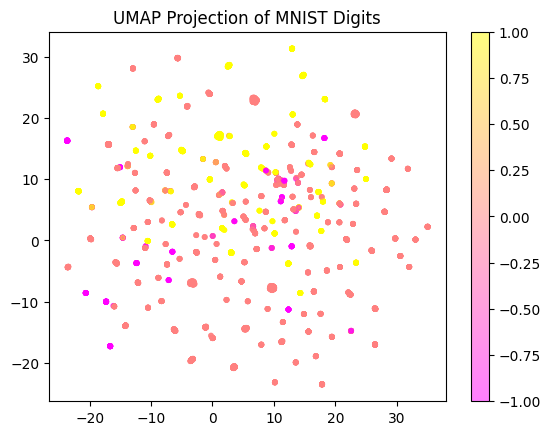

In [44]:
labels = np.zeros(df_clean.shape[0])
for i, line in enumerate(df_clean['listed_in']):
    if 'Comedies' in line:
        labels[i] = 1
    if 'Horror' in line:
        labels[i] = -1


# Plot the result
plt.scatter(reduction[:, 0], reduction[:, 1], cmap = 'spring', c=labels, s=10, alpha=0.5) 
plt.colorbar() 
#plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP Projection of MNIST Digits')
plt.show()

In [81]:
def CosineSimilarity(z, X, sort_idx = False):
    norm = (np.linalg.norm(z) * np.linalg.norm(X, axis=1, keepdims=True))
    cosine_similarity = ((X @ z.T) / norm).squeeze()
    
    idx = np.argsort(-cosine_similarity.squeeze()) if sort_idx else None

    return cosine_similarity, idx

<br>